In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet
from prophet.diagnostics import cross_validation
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error


In [2]:
data = pd.read_csv('T10Y2Y.csv', na_values='.')
data['DATE'] = pd.to_datetime(data['DATE'])
data = data.dropna(axis=0, how='any', )
data['T10Y2Y'] = data['T10Y2Y'].astype(float)
data.rename(columns={'DATE': 'ds', 'T10Y2Y': 'y'}, inplace=True)
data.head()

,ds,y
0,2019-07-18,0.27
1,2019-07-19,0.25
2,2019-07-22,0.25
3,2019-07-23,0.25
4,2019-07-24,0.22


**Перетворив дату з object на datetime та таргет на float, перетворив назву стовпців на такі, що сприймає бібліотека**

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1252 entries, 0 to 1305
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      1252 non-null   datetime64[ns]
 1   y       1252 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 29.3 KB


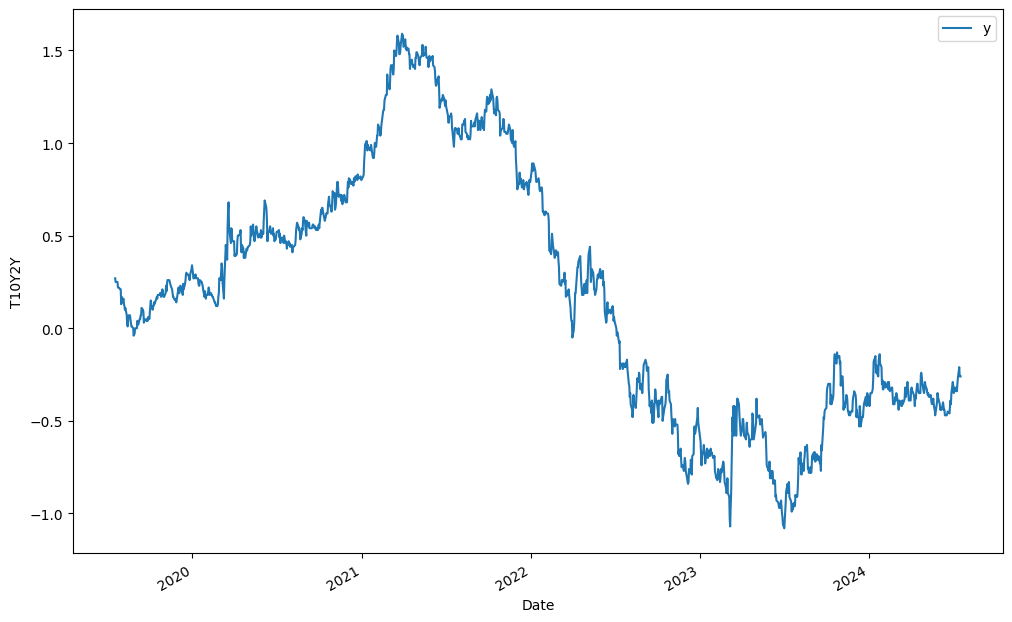

In [4]:
ax = data.set_index('ds').plot(figsize=(12, 8))
ax.set_ylabel('T10Y2Y')
ax.set_xlabel('Date')

plt.show()

**Графік зміни таргета від часу**

In [5]:
data['lag1'] = data['y'].shift(1)
data['lag2'] = data['y'].shift(2)
data['rolling_mean'] = data['y'].rolling(window=3).mean()
data['rolling_std'] = data['y'].rolling(window=3).std()
data['frequency'] = np.fft.fftfreq(len(data['y']))
data['amplitude'] = np.abs(np.fft.fft(data['y']))
data = data.dropna(axis=0, how='any', )
data.head()

,ds,y,lag1,lag2,rolling_mean,rolling_std,frequency,amplitude
2,2019-07-22,0.25,0.25,0.27,0.256667,0.011547,0.001597,160.564453
3,2019-07-23,0.25,0.25,0.25,0.250000,0.000000,0.002396,47.104744
4,2019-07-24,0.22,0.25,0.25,0.240000,0.017321,0.003195,50.442971
5,2019-07-25,0.22,0.22,0.25,0.230000,0.017321,0.003994,21.631945
6,2019-07-26,0.22,0.22,0.22,0.220000,0.000000,0.004792,29.833154


**feature engineering та прибирання пропусків**

In [6]:
model = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False, changepoint_prior_scale=0.5, seasonality_prior_scale=0.01)
model.fit(data)

15:50:06 - cmdstanpy - INFO - Chain [1] start processing
15:50:06 - cmdstanpy - INFO - Chain [1] done processing


**Модель з підібраними гіперпараметрами**

In [7]:
future = model.make_future_dataframe(periods=30, freq='D')

forecast = model.predict(future)

forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
1275,2024-08-13,-0.183645,-0.329097,-0.035047
1276,2024-08-14,-0.182382,-0.330516,-0.030861
1277,2024-08-15,-0.181119,-0.323450,-0.034482
1278,2024-08-16,-0.179857,-0.320980,-0.030193
1279,2024-08-17,-0.178594,-0.318623,-0.020703


In [8]:
data_cv = cross_validation(model, initial='730 days', period='180 days', horizon='365 days')

mae = mean_absolute_error(data_cv['y'], data_cv['yhat'])
mse = mean_squared_error(data_cv['y'], data_cv['yhat'])
rmse = root_mean_squared_error(data_cv['y'], data_cv['yhat'])

print(f'Mean Absolute Error: {mae:.2f}')
print(f'Mean Squared Error: {mse:.2f}')
print(f'Root Mean Squared Error: {rmse:.2f}')

  0%|          | 0/5 [00:00<?, ?it/s]

15:50:06 - cmdstanpy - INFO - Chain [1] start processing
15:50:07 - cmdstanpy - INFO - Chain [1] done processing
15:50:07 - cmdstanpy - INFO - Chain [1] start processing
15:50:07 - cmdstanpy - INFO - Chain [1] done processing
15:50:07 - cmdstanpy - INFO - Chain [1] start processing
15:50:07 - cmdstanpy - INFO - Chain [1] done processing
15:50:08 - cmdstanpy - INFO - Chain [1] start processing
15:50:08 - cmdstanpy - INFO - Chain [1] done processing
15:50:08 - cmdstanpy - INFO - Chain [1] start processing
15:50:08 - cmdstanpy - INFO - Chain [1] done processing


Mean Absolute Error: 0.54
Mean Squared Error: 0.47
Root Mean Squared Error: 0.69


**Оцінка точності моделі**

C:\Users\gergi_6afqda2\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\prophet\plot.py:72: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()
C:\Users\gergi_6afqda2\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\prophet\plot.py:73: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  ax.plot(m.history['ds'].dt.to_pydatetime(), m.history['y'], 'k.',


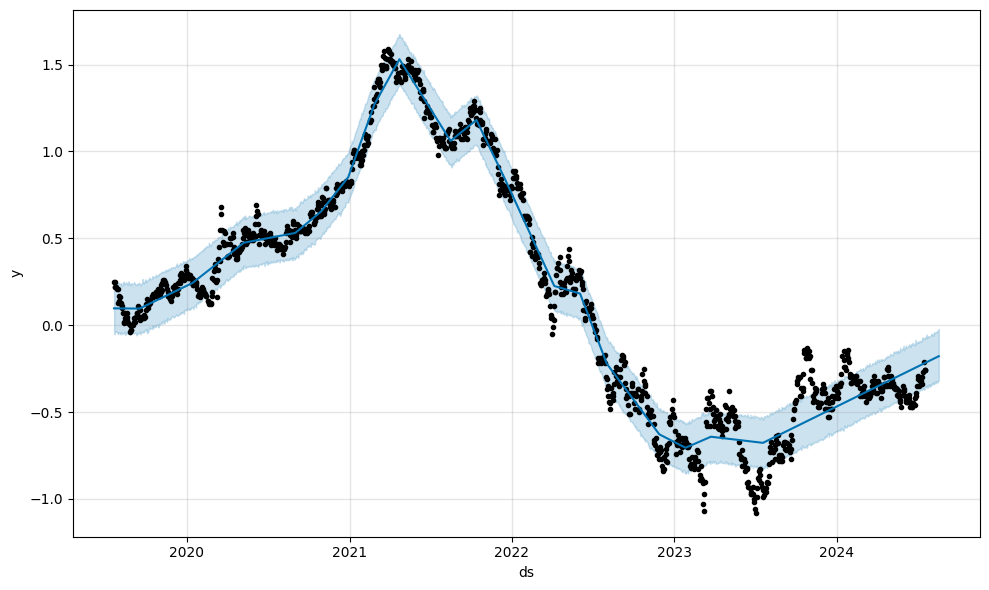

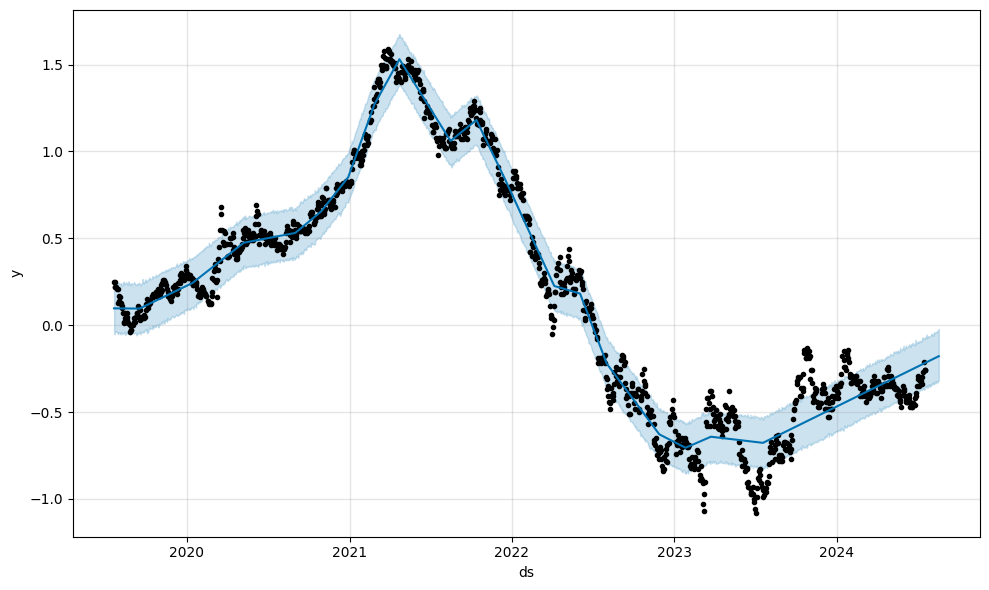

In [9]:
model.plot(forecast, uncertainty=True)

**Графік з передбаченими даними**